<a href="https://colab.research.google.com/github/JonaEmmOfCruz/Machine-learning/blob/main/Hands-on%201/Hands_on_1_SLR_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><strong>Regresión lineal</strong></h1>

<br>

La regresión lineal es un método para predecir una o más variables a partir de otras variables. Las variables que se predicen se denominan **variables dependientes (y)** , y las variables que se predicen con su ayuda se denominan **variables independientes (x)**.

**Si solo hay una variable independiente**, el modelo de regresión lineal se denomina `simple`, de ​​lo contrario, se denomina `múltiple`.

<br><br>

<h3><strong>Regresión lineal simple</strong></h3>

La regresión lineal simple mide la relación entre una variable independiente y una variable dependiente , así como la correlación entre ellas.

> **Objetivo:** es encontrar la línea recta que mejor se ajuste y describa la relación entre $x_{i}$ y $y_{i}$ .

Esto se representa por la siguiente ecuación:

> $y_{pred} = w ⋅ x + b$ <br>

Donde:

* $y_{pred}$ es la salida **prevista**.
* $w$ es la pendiente de la línea.
* $b$ es la intersección con el eje $y$ de la línea.

<br><br>

<h3><strong>Expresión para el valor predicho</strong></h3>

Para una entrada dada $x_{i}$, la salida predicha $y_{pred(i)}$ se calcula como:

<br>

> $y_{\text{pred}}^{(i)} = w ⋅ x_{i} + b$

<br>

<h3><strong>Expresión para la función de pérdida</strong></h3>

La función de pérdida mide qué tan bien coinciden los valores predichos $y^{i}$ con los valores reales ( yi ). Para la regresión lineal simple, se suele utilizar el **error cuadrático medio (ECM):**

<br>

> $MSE = \frac{1}{n}\sum_{i=1}^{n} (w \cdot x_{i} + b - y_{\text{true}}^{(i)})^2$

<br><br>

<h3><strong>Implementación en Python de la regresión lineal simple</strong></h3>

In [ ]:
# Librería para cálculo numérico y manipulación de vectores
import numpy as np

"""
    Esta función calcula la predicción de una regresión lineal simple y
    devuelve los valores predichos por el modelo.

"""
def predict(x, w, b):
    return w * x + b

"""
    Esta función calcula la función de pérdida del Error Cuadrático Medio y
    devuelve el promedio de las diferencias al cuadrado entre predicción y valor real.

"""
def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)


# Variable independiente
x = np.array([1, 2, 3, 4, 5])

# Variable dependiente
y_true = np.array([2, 4, 5, 4, 5])

# Parámetros del modelo
w = 0.8 # Peso
b = 1.0 # Sesgo

# Generar las predicciones vectorizadas para todos los puntos en x
y_pred = predict(x, w, b)

# Calcular la métrica de error
loss = mse_loss(y_pred, y_true)

print(f"Valores predichos: {y_pred}")
print(f"Pérdida MSE: {loss:.3f}")

Valores predichos: [1.8 2.6 3.4 4.2 5. ]
Pérdida MSE: 0.920


<h3><strong>Visualización de la relación entre el tamaño del motor y las emisiones de CO2 mediante regresión lineal.</strong></h3>

<h4><strong>Paso 1: Crear los datos</strong></h4>

Se crea un conjunto de datos con dos columnas:
`Engine_size` y `CO2_Emissions`

In [ ]:
# Librería para el manejo y estructuración de datos en tablas
import pandas as pd

# Librería para cálculos numéricos y generación de arreglos/datos aleatorios
import numpy as np

# Librería para crear gráficos y visualizar datos
import matplotlib.pyplot as plt

# Fijar la semilla para reproducibilidad
np.random.seed(42)

"""
  Generar 100 tamaños de motor distribuidos entre 1.5 y 4.5
"""
engine_sizes = np.linspace(1.5, 4.5, 100)
slope = 60
intercept = 50

"""
  Generar ruido aleatorio
"""
noise = np.random.normal(0, 15, size=engine_sizes.shape)
co2_emissions = slope * engine_sizes + intercept + noise

"""
  Crear un DataFrame con los datos generados
"""
df = pd.DataFrame({'Engine_size': engine_sizes,
                   'CO2_Emissions': co2_emissions})

df.head()

,Engine_size,CO2_Emissions
0,1.500000,147.450712
1,1.530303,139.744217
2,1.560606,153.351692
3,1.590909,168.299993
4,1.621212,143.760427


<h4><strong>Paso 2: Muestra los datos en un diagrama de dispersión.
</strong></h4>

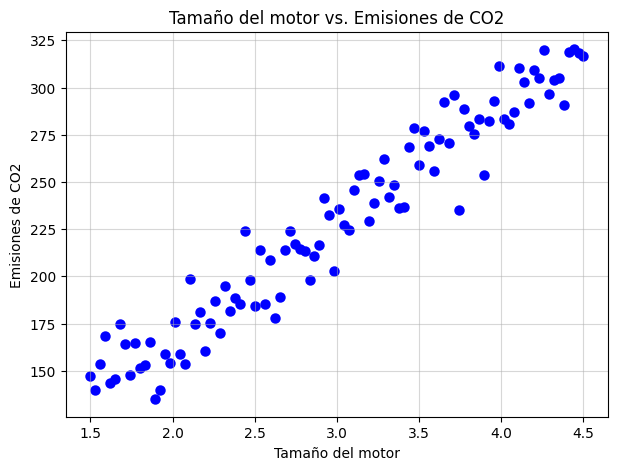

In [ ]:
plt.figure(figsize=( 7 , 5 )) # Define el tamaño del lienzo/figura
plt.scatter(
    df[ 'Engine_size' ],     # Son los valores para el eje X
    df[ 'CO2_Emissions' ],   # Son los valores para el eje Y
    color= 'b' , edgecolors= 'b' ,
    linewidths= 1.5
)

plt.xlabel( 'Tamaño del motor' )
plt.ylabel( 'Emisiones de CO2' )
plt.title( 'Tamaño del motor vs. Emisiones de CO2' )
plt.grid(alpha= 0.5 )
plt.show()

<h4><strong>Paso 3: Generación de líneas de regresión con diferentes parámetros
</strong></h4>

Se pueden trazar diferentes líneas cambiando distintos valores de **a** y **b**. <br> Aquí está el código que crea cuatro gráficos separados para visualizar los efectos de variar los parámetros **a** y **b** en el modelo de regresión lineal:

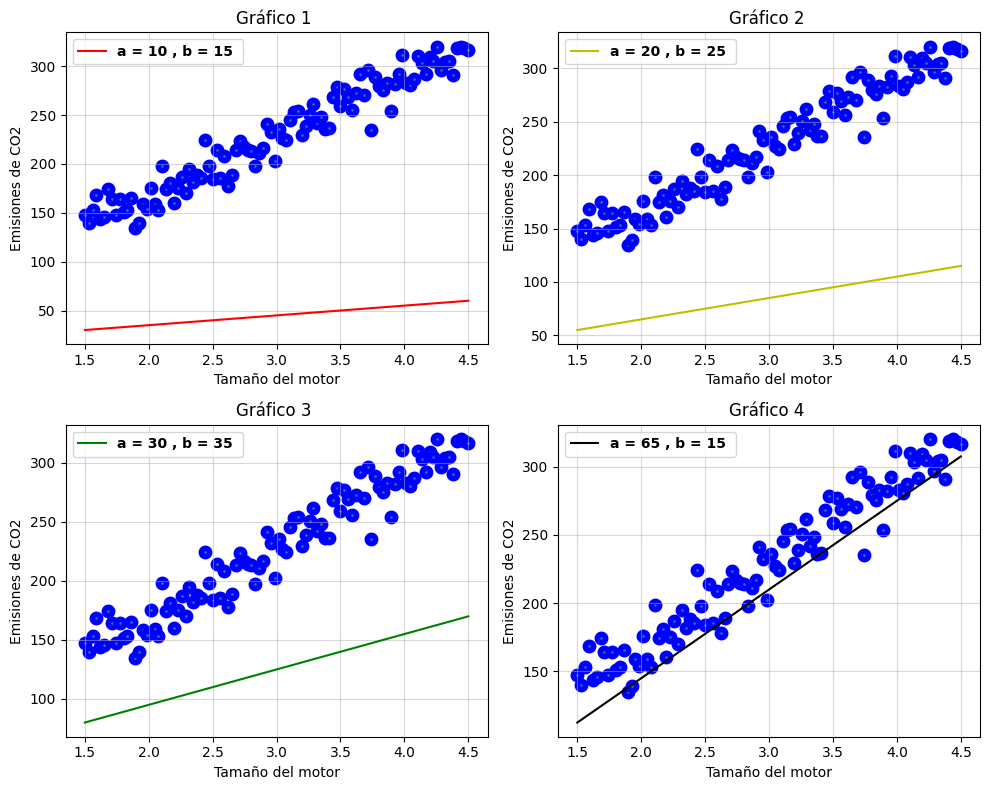

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preparar la gráfica
fig, axs = plt.subplots( 2 , 2 , figsize=( 10 , 8 ))
legend_properties = { 'weight' : 'bold' }

# Definir los diferentes parámetros a y b para las gráficas
params = [
    ( 10 , 15 , 'r' ),
    ( 20 , 25 , 'y' ),
    ( 30 , 35 , 'g' ),
    ( 65 , 15 , 'k' )
]

# Convierte la matriz 2x2 en un arreglo unidimensional de 4
for i, ax in  enumerate (axs.flatten()):

    # Extraer la pendiente (a), intersección (b) y el color
    a, b, color = params[i]

    # Generar 100 puntos en el eje X
    x = np.linspace( 1.5 , 4.5 , 100 )   # Definir el rango para Engine_size

    # Diagrama de dispersión
    x_scatter = df[ 'Engine_size' ]
    y_scatter = df[ 'CO2_Emissions' ]
    ax.scatter(x_scatter, y_scatter, edgecolors= 'b' , linewidths= 4. )

    # Calcula los valores estimados según la ecuación lineal
    y = a * x + b
    ax.plot(x, y, color, label= f'a = {a} , b = {b} ' )

    # Etiquetas y cuadrícula
    ax.set_xlabel( 'Tamaño del motor' )
    ax.set_ylabel( 'Emisiones de CO2' )
    ax.legend(prop=legend_properties)
    ax.grid(alpha= 0.5 )
    ax.set_title( f'Gráfico {i + 1 } ' )

# Ajustar el diseño
plt.tight_layout()
plt.show()

<h3><strong>Funciones de pérdida en regresión</strong></h3>

<h4><strong>1. Error absoluto medio o MAE</strong></h4>

Es una de las funciones de pérdida más simples e intuitivas utilizadas en tareas de regresión. Mide la magnitud promedio de los errores entre los valores predichos y los reales, sin considerar su dirección (es decir, positiva o negativa).

<br>

<h4><strong>Expresión matemática para MAE:</strong></h4>

> $MAE = \frac{1}{n}\sum_{i=1}^{n} |y_{\text{pred}}^{(i)} - y_{\text{true}}^{(i)}| $

<br>

Donde:

* $n$ es el número de puntos de datos.
* $y_{\text{pred}}^{(i)}$ es el valor predicho para el i -ésimo punto de datos.
* $y_{\text{true}}^{(i)}$ es el valor real para el i -ésimo punto de datos.

<br>

<h4><strong>Implementación en Python de MAE</strong></h4>

In [ ]:
import numpy as np


def mae_loss(y_pred, y_true):
    """Calcula el Error Absoluto Medio (MAE) entre los valores predichos y verdaderos y
    devuele el Error Absoluto Medio.
    """
    # Validación de entrada
    if not isinstance(y_pred, np.ndarray) or not isinstance(y_true, np.ndarray):
        raise ValueError("Las entradas deben ser matrices NumPy.")

    if y_pred.shape != y_true.shape:
        raise ValueError("Las matrices de entrada deben tener la misma forma.")

    if y_true.size == 0:
        raise ValueError("Las matrices de entrada no deben estar vacías.")

    # Calcular el error absoluto medio
    loss = np.mean(np.abs(y_pred - y_true))

    return loss


# Datos de ejemplo
y_true = np.array([3.0, -0.5, 2.0, 7.0])  # Valores reales
y_pred = np.array([2.5, 0.0, 2.0, 8.0])  # Valores predichos

# Calcular MAE
loss = mae_loss(y_pred, y_true)

print(f"Pérdida MAE: {loss}")

Pérdida MAE: 0.5


<h4><strong>2. Error cuadrático medio o ECM</strong></h4>

Es una de las funciones de pérdida más utilizadas en tareas de regresión. Mide el promedio de las diferencias al cuadrado entre los valores reales `$y_{\text{true}}$` y los valores predichos `$y_{\text{y_predicho}}$`. Elevar al cuadrado los errores garantiza que los errores mayores se penalicen más, lo que hace que el MSE sea sensible a los valores atípicos.

<br>

<h4><strong>Expresión matemática para ESM:</strong></h4>

> $MSE = \frac{1}{n}\sum_{i=1}^{n} (y_{\text{pred}}^{(i)} - y_{\text{true}}^{(i)})^2 $

<br>

Donde:

* $n$ es el número de puntos de datos.
* $y_{\text{pred}}^{(i)}$ es el valor predicho para el i -ésimo punto de datos.
* $y_{\text{true}}^{(i)}$ es el valor real para el i -ésimo punto de datos.

<br>

<h4><strong>Implementación en Python de ESM</strong></h4>

In [ ]:
import numpy as np


def mse_loss(y_pred, y_true):
    """Calcula el error cuadrático medio (MSE) entre los valores predichos y verdaderos.
    devuelve el error cuadrático medio.
    """
    # Validación de entrada
    if not isinstance(y_pred, np.ndarray) or not isinstance(y_true, np.ndarray):
        raise ValueError("Las entradas deben ser matrices NumPy.")

    if y_pred.shape != y_true.shape:
        raise ValueError("Las matrices de entrada deben tener la misma forma.")

    if y_true.size == 0:
        raise ValueError("Las matrices de entrada no deben estar vacías.")

    # Calcular el error cuadrático medio
    loss = np.mean((y_pred - y_true) ** 2)

    return loss


# Datos de ejemplo
y_true = np.array([3.0, -0.5, 2.0, 7.0])  # Valores reales
y_pred = np.array([2.5, 0.0, 2.0, 8.0])  # Valores predichos

# Calcular MSE
loss = mse_loss(y_pred, y_true)

print(f"MSE Loss: {loss}")

MSE Loss: 0.375


<h3><strong>Comparación de MAE y MSE</strong></h3>

| Feature | MAE (Mean Absolute Error) | MSE (Mean Squared Error) |
| :-- | :-- | :-- |
| Sensitivity to Outliers | Less sensitive | Highly sensitive |
| Differentiability | Non-differentiable at zero | Differentiable everywhere |
| Interpretability | Easier to interpret | Harder to interpret |
| Use case | Robust to outliers | Emphasizes large errors |

<br>

<h4><strong>Visualización de las funciones de pérdida MAE y MSE</strong></h4>

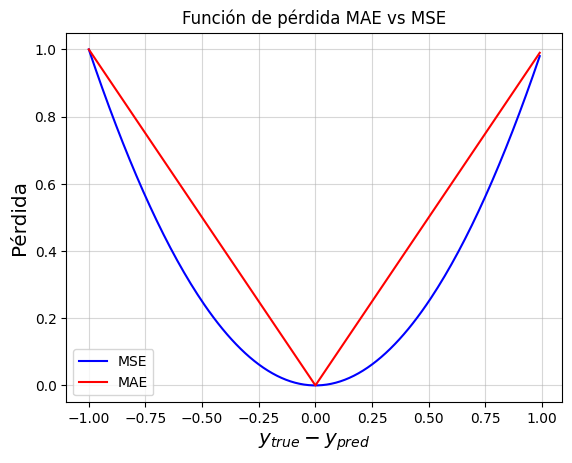

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Grafica el error MSE
x_mse = np.arange(-1, 1, 0.01)
y_mse = np.square(x_mse)
plt.plot(x_mse, y_mse, color="blue", label="MSE")
plt.grid(True, which="major", alpha=0.5)

# Grafica el error MAE
x_mae = np.arange(-1, 1, 0.01)
y_mae = np.abs(x_mae)
plt.plot(x_mae, y_mae, color="red", label="MAE")
plt.grid(True, which="major", alpha=0.5)

# Etiquetas y título
plt.xlabel("$y_{true} - y_{pred}$", size="x-large")
plt.ylabel("Pérdida", size="x-large")
plt.title("Función de pérdida MAE vs MSE")
plt.legend()

# Mostrar el gráfico
plt.show()

<h3><strong>R cuadrado</strong></h3>

> $R^{2} = 1 - \frac{\frac{1}{n}\sum_{i=1}^{n}(y_{i} - \hat{y}_{i})^2}{\frac{1}{n}\sum_{i=1}^{n} (y_i - \bar{y}_i)^2}$

El denominador de la fracción y̅ se refiere a la media de los datos o etiquetas objetivo, y los demás elementos son los mismos que el MSE que se ha explicado anteriormente.

In [ ]:
from sklearn.metrics import r2_score

# Valores reales
actual = [ 1 , 2 , 3 , 4 , 5 ]

# Valores predichos
predicted = [ 1.2 , 1.8 , 3.2 , 3.9 , 4.7 ]

# Calcular el coeficiente de determinación (R)
r2 = r2_score(actual, predicted)

print ( "R²: " , r2)
# R²: 0.978

R²:  0.978


<h3><strong>Entrenamiento del modelo de regresión lineal
</strong></h3>

En el proceso de entrenamiento de modelos de aprendizaje automático, se suele considerar una proporción del **80%** para los datos de entrenamiento y del **20%** para los datos de prueba.

<h4><strong>Importaciones</strong></h4>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

<h4><strong>Cargar el conjunto de datos</strong></h4>

In [ ]:
# 1. Montar tu Google Drive
drive.mount('/content/drive')

# 2. Definir la ruta del archivo
ruta = '/content/drive/MyDrive/Colab Notebooks/dataset/Advertising.csv'

# 3. Leer el archivo CSV
df = pd.read_csv(ruta)

# 4. Eliminar la primera columna
df = df.iloc[:, 1:]

# 5. Mostrar las primeras filas
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


<h4><strong>Seleccione una característica</strong></h4>

In [ ]:
# Selección de columnas con el nombre en inglés
df_new = df[["TV", "Sales"]]
df_new.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [ ]:
type(df_new) # pandas.core.frame.DataFrame

pandas.core.frame.DataFrame

<h4><strong>Convertir a NumPy</strong></h4>

In [ ]:
# Convierte el DataFrame filtrado (df_new) a un array de NumPy
dataset = np.array(df_new)

<h4><strong>División de prueba de tren</strong></h4>

In [ ]:
# Extrae los valores del array en la primera columna y asígnalos a la variable 'x'.
x = dataset[:, 0 ]
y = dataset[:, 1 ]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print (x_train.shape) # (160,)
print (y_train.shape) # (160,)
print (x_test.shape)   # (40,)
print (y_test.shape)   # (40,)

(160,)
(160,)
(40,)
(40,)


<h4><strong>Visualización</strong></h4>

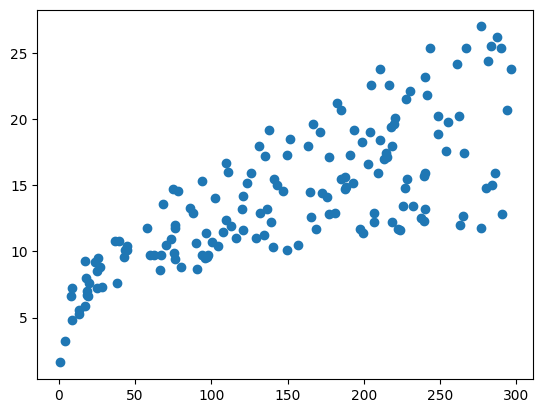

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x_train, y_train);

<h4><strong>Modelo</strong></h4>

In [ ]:
# Convierte x_train de un vector a una matriz
x_train = x_train.reshape( -1 , 1 )

# Convierte y_train en una matriz para mantener consistencia de dimensiones
y_train = y_train.reshape( -1 , 1 )


In [ ]:
"""
  Consultar la estructura y las dimensiones de x_train e y_train y
  retorna una tupla con las formas de ambos arreglos
"""
x_train.shape, y_train.shape


((160, 1), (160, 1))

In [ ]:

from sklearn.linear_model import LinearRegression

model = LinearRegression()

"""
  Entrenar el modelo utilizando los datos de entrenamiento y
  calcula internamente la pendiente y el punto de corte óptimos
"""
model.fit(x_train, y_train)



LinearRegression()

In [ ]:
# Obtiene los parámetros optimizados  del modelo tras del entrenamiento
model.coef_, model.intercept_

(array([[0.04652973]]), array([7.11963843]))

<h4><strong>Calcular la pérdida para el modelo entrenado:</strong></h4>

In [ ]:
# Calcular los valores predichos
y_pred = model.predict(x_train)

# Calcular la pérdida (error cuadrático medio)
loss = np.mean((y_train - y_pred) ** 2 )
print (loss)   # 10.60

10.603600570989268


<h4><strong>Graficar la función</strong></h4>

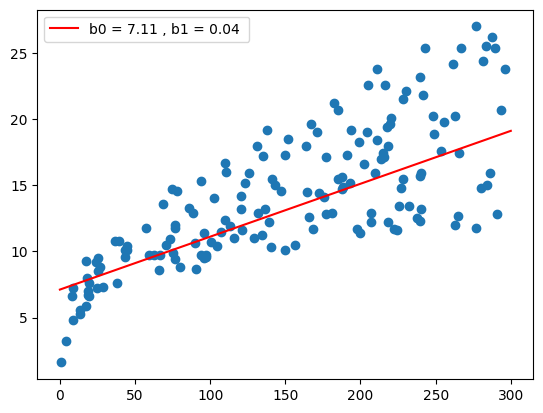

In [ ]:
# Grafica los datos reales de entrenamiento
plt.scatter(x_train, y_train);

# Genera 100 puntos distribuidos uniformemente entre 0 y 300
x = np.linspace( 0 , 300 , 100 )

b0 = 7.11
b1 = 0.04

# Calcula los valores predichos aplicando la ecuación de la recta
y_hat = b0 + b1*x

# Grafica la recta estimada
plt.plot(x, y_hat, 'r' , label= f'b0 = {b0} , b1 = {b1} ' );
plt.legend()